In [1]:
!pip install cassandra-driver matplotlib --quiet

In [9]:
from cassandra.cluster import Cluster
import pandas as pd

cluster = Cluster(['cassandra'], port=9042)
session = cluster.connect('vols')

# Récupération des 3 tables principales sous forme de DataFrame pandas
rows_compagnie = session.execute("SELECT * FROM retards_par_compagnie")
df_compagnie = pd.DataFrame(list(rows_compagnie))

rows_aeroport = session.execute("SELECT * FROM retards_par_aeroport")
df_aeroport = pd.DataFrame(list(rows_aeroport))

rows_jour = session.execute("SELECT * FROM retards_par_jour")
df_jour = pd.DataFrame(list(rows_jour))

rows_aeroport_jour = session.execute("SELECT * FROM retards_par_aeroport_jour")
df_aeroport_jour = pd.DataFrame(list(rows_aeroport_jour))


print(df_compagnie.shape, df_aeroport.shape, df_jour.shape, df_aeroport_jour.shape)
df_compagnie.head()

(20, 5) (171, 5) (7, 6) (1086, 7)


,compagnie,nb_retards,nb_vols,retard_moyen,taux_retard
0,AQ,27,50,21.959999,54.000000
1,XE,5461,8021,50.200001,68.080002
2,YV,3772,5111,53.900002,73.800003
3,OO,6776,10227,45.610001,66.260002
4,F9,1202,2198,28.870001,54.689999


#### taux de retard par compagnie

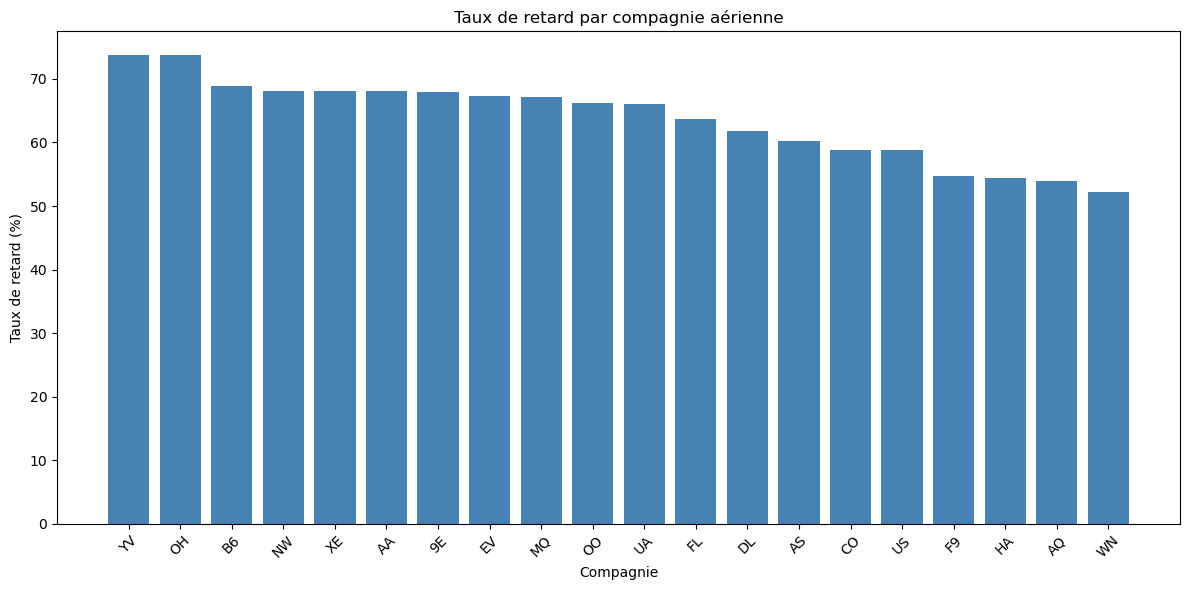

In [3]:
import matplotlib.pyplot as plt

df_compagnie_sorted = df_compagnie.sort_values("taux_retard", ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(df_compagnie_sorted["compagnie"], df_compagnie_sorted["taux_retard"], color="steelblue")
plt.xlabel("Compagnie")
plt.ylabel("Taux de retard (%)")
plt.title("Taux de retard par compagnie aérienne")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("/home/jovyan/data/graph_compagnie.png")
plt.show()

#### taux de retard par jour de la semaine

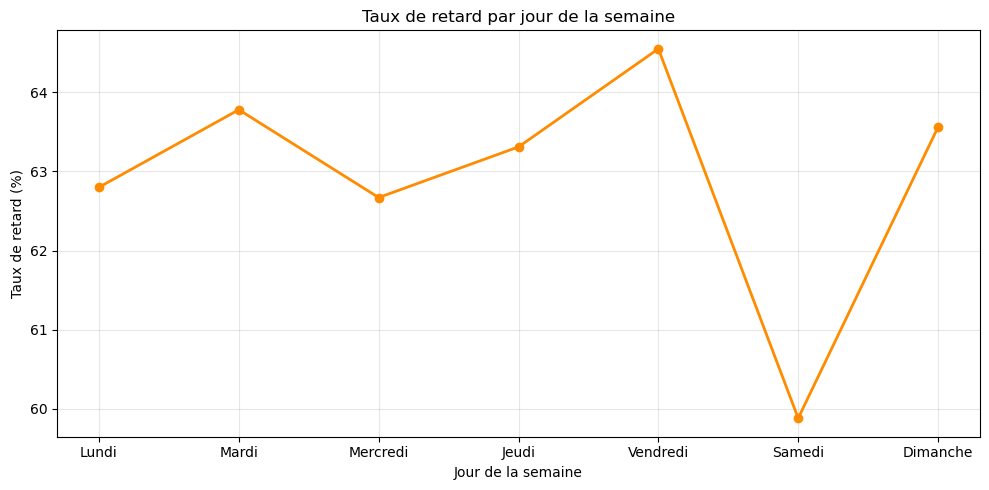

In [4]:
df_jour_sorted = df_jour.sort_values("jour_semaine")

plt.figure(figsize=(10, 5))
plt.plot(df_jour_sorted["nom_jour"], df_jour_sorted["taux_retard"], marker="o", color="darkorange", linewidth=2)
plt.xlabel("Jour de la semaine")
plt.ylabel("Taux de retard (%)")
plt.title("Taux de retard par jour de la semaine")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/home/jovyan/data/graph_jour.png")
plt.show()

#### top 15 aéroports les plus en retard

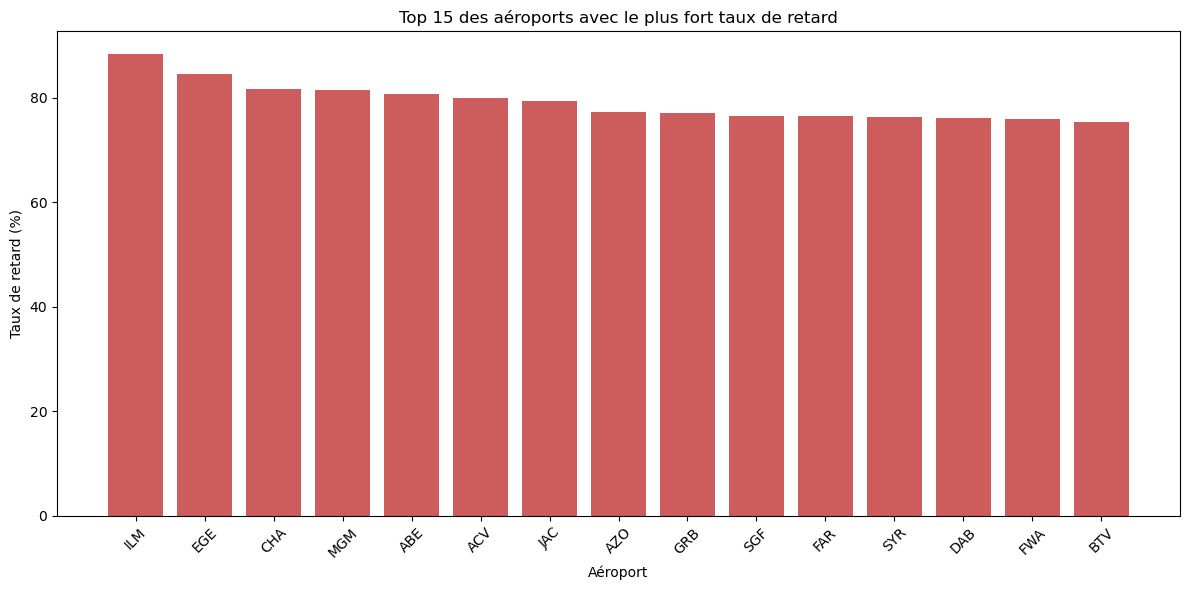

In [7]:
df_aeroport_top15 = df_aeroport.sort_values("taux_retard", ascending=False).head(15)

plt.figure(figsize=(12, 6))
plt.bar(df_aeroport_top15["aeroport"], df_aeroport_top15["taux_retard"], color="indianred")
plt.xlabel("Aéroport")
plt.ylabel("Taux de retard (%)")
plt.title("Top 15 des aéroports avec le plus fort taux de retard")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("/home/jovyan/data/graph_aeroport.png")
plt.show()

#### Taux de retard par jour, pour les aéroports les plus en retard

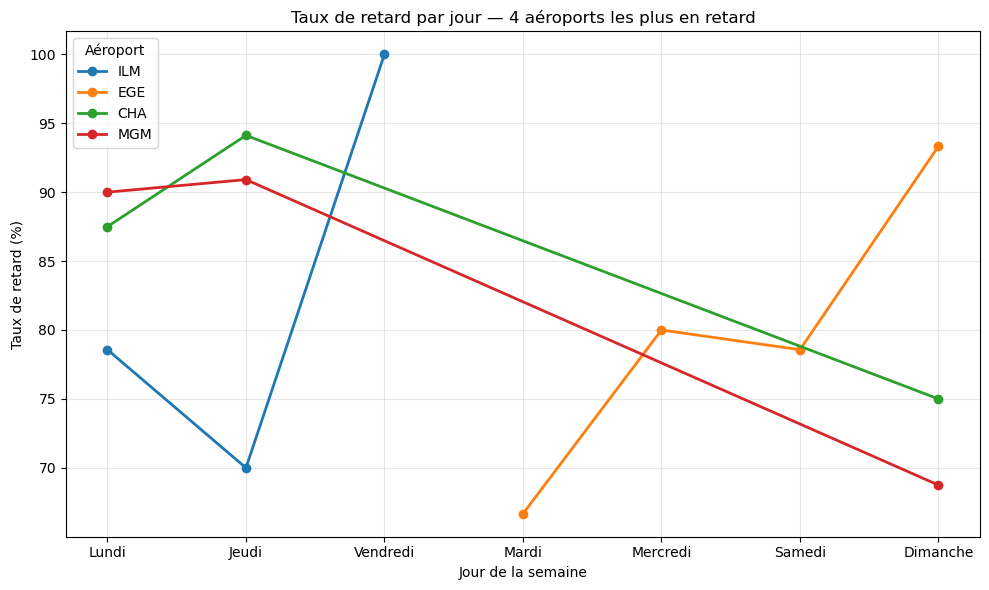

In [10]:
# On récupère les 4 aéroports avec le pire taux de retard moyen (toutes journées confondues)
pires_aeroports = df_aeroport.sort_values("taux_retard", ascending=False).head(4)["aeroport"].tolist()

plt.figure(figsize=(10, 6))

for aero in pires_aeroports:
    subset = df_aeroport_jour[df_aeroport_jour["aeroport"] == aero].sort_values("jour_semaine")
    plt.plot(subset["nom_jour"], subset["taux_retard"], marker="o", linewidth=2, label=aero)

plt.xlabel("Jour de la semaine")
plt.ylabel("Taux de retard (%)")
plt.title("Taux de retard par jour — 4 aéroports les plus en retard")
plt.legend(title="Aéroport")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/home/jovyan/data/graph_aeroport_jour.png")
plt.show()